In [ ]:
# Step 1: Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# Training dataset
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Testing dataset
test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))



100%|██████████| 170M/170M [19:34<00:00, 145kB/s]


Training samples: 50000
Testing samples: 10000


In [ ]:
class CNN(nn.Module):

    def __init__(self, dropout=False):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

        self.use_dropout = dropout

    def forward(self, x):

        x = torch.relu(self.conv1(x))
        x = self.pool(x)

        x = torch.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(-1, 64 * 8 * 8)

        x = torch.relu(self.fc1(x))

        if self.use_dropout:
            x = self.dropout(x)

        x = self.fc2(x)

        return x


In [ ]:
def train_model(model, optimizer, epochs=5):

    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_losses = []

    train_accuracies = []
    test_accuracies = []

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        # -------------------------
        # Testing
        # -------------------------
        model.eval()

        test_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                test_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_loss = test_loss / len(test_loader)
        test_accuracy = 100 * correct / total

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_accuracy:.2f}% "
            f"Test Loss: {test_loss:.4f} "
            f"Test Acc: {test_accuracy:.2f}%"
        )

    return train_losses, test_losses, train_accuracies, test_accuracies

In [ ]:
print("\n==============================")
print("MODEL 1: NORMAL CNN")
print("==============================")

model_normal = CNN(dropout=False).to(device)

optimizer_normal = optim.Adam(
    model_normal.parameters(),
    lr=0.001
)

normal_results = train_model(
    model_normal,
    optimizer_normal,
    epochs=5
)


# ============================================================
# Step 6: Model 2 - CNN with Dropout
# ============================================================

print("\n==============================")
print("MODEL 2: CNN + DROPOUT")
print("==============================")

model_dropout = CNN(dropout=True).to(device)

optimizer_dropout = optim.Adam(
    model_dropout.parameters(),
    lr=0.001
)

dropout_results = train_model(
    model_dropout,
    optimizer_dropout,
    epochs=5
)


# ============================================================
# Step 7: Model 3 - CNN with L2 Weight Decay
# ============================================================

print("\n==============================")
print("MODEL 3: CNN + L2 WEIGHT DECAY")
print("==============================")

model_l2 = CNN(dropout=False).to(device)

optimizer_l2 = optim.Adam(
    model_l2.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

l2_results = train_model(
    model_l2,
    optimizer_l2,
    epochs=5
)




MODEL 1: NORMAL CNN
Epoch [1/5] Train Loss: 1.4470 Train Acc: 48.30% Test Loss: 1.1855 Test Acc: 57.34%
Epoch [2/5] Train Loss: 1.0665 Train Acc: 62.42% Test Loss: 1.0108 Test Acc: 64.68%
Epoch [3/5] Train Loss: 0.9148 Train Acc: 67.94% Test Loss: 0.9570 Test Acc: 66.33%
Epoch [4/5] Train Loss: 0.8052 Train Acc: 71.85% Test Loss: 0.8613 Test Acc: 69.84%
Epoch [5/5] Train Loss: 0.7196 Train Acc: 74.86% Test Loss: 0.8381 Test Acc: 70.95%

MODEL 2: CNN + DROPOUT
Epoch [1/5] Train Loss: 1.5989 Train Acc: 42.13% Test Loss: 1.2526 Test Acc: 54.82%
Epoch [2/5] Train Loss: 1.2734 Train Acc: 54.27% Test Loss: 1.0824 Test Acc: 61.75%
Epoch [3/5] Train Loss: 1.1203 Train Acc: 60.31% Test Loss: 0.9729 Test Acc: 65.79%
Epoch [4/5] Train Loss: 1.0287 Train Acc: 63.77% Test Loss: 0.9072 Test Acc: 68.08%
Epoch [5/5] Train Loss: 0.9548 Train Acc: 66.54% Test Loss: 0.8882 Test Acc: 68.96%

MODEL 3: CNN + L2 WEIGHT DECAY
Epoch [1/5] Train Loss: 1.4068 Train Acc: 49.64% Test Loss: 1.1588 Test Acc: 58.32%

In [ ]:
normal_test_accuracy = normal_results[3][-1]
dropout_test_accuracy = dropout_results[3][-1]
l2_test_accuracy = l2_results[3][-1]

print("\n==============================")
print("FINAL TEST ACCURACIES")
print("==============================")

print(f"Normal CNN       : {normal_test_accuracy:.2f}%")
print(f"CNN + Dropout    : {dropout_test_accuracy:.2f}%")
print(f"CNN + L2 Decay   : {l2_test_accuracy:.2f}%")


FINAL TEST ACCURACIES
Normal CNN       : 70.95%
CNN + Dropout    : 68.96%
CNN + L2 Decay   : 71.37%


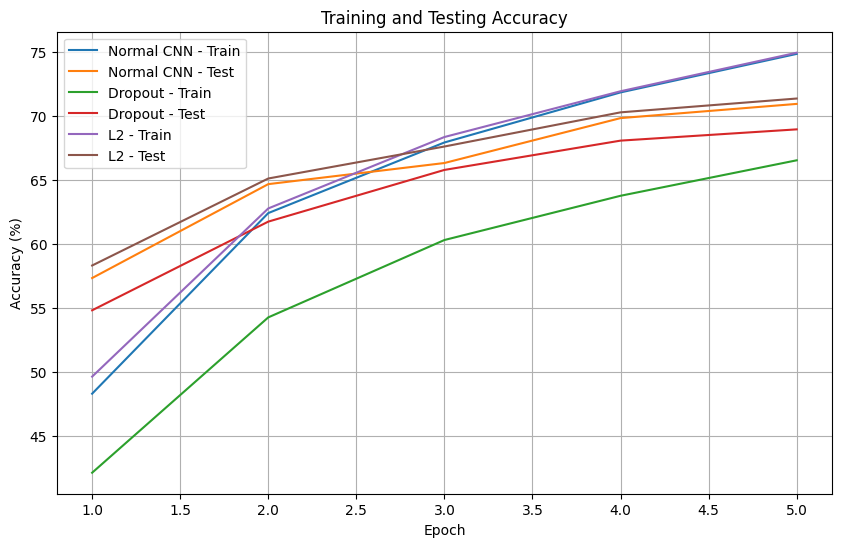

In [ ]:
epochs = range(1, 6)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    normal_results[2],
    label="Normal CNN - Train"
)

plt.plot(
    epochs,
    normal_results[3],
    label="Normal CNN - Test"
)

plt.plot(
    epochs,
    dropout_results[2],
    label="Dropout - Train"
)

plt.plot(
    epochs,
    dropout_results[3],
    label="Dropout - Test"
)

plt.plot(
    epochs,
    l2_results[2],
    label="L2 - Train"
)

plt.plot(
    epochs,
    l2_results[3],
    label="L2 - Test"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Testing Accuracy")
plt.legend()
plt.grid()

plt.show()

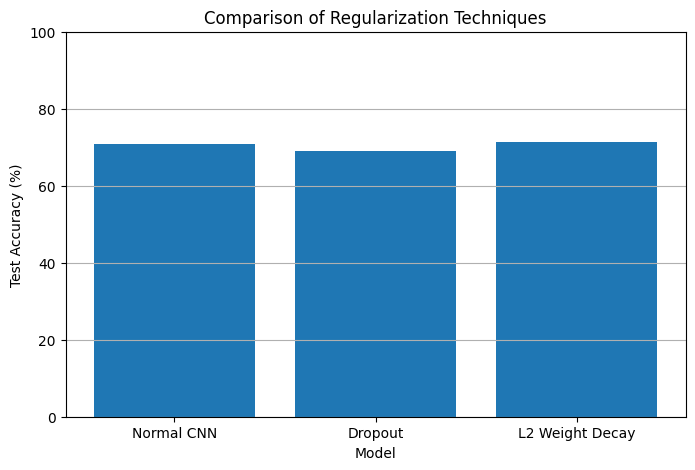

In [ ]:
models = [
    "Normal CNN",
    "Dropout",
    "L2 Weight Decay"
]

accuracies = [
    normal_test_accuracy,
    dropout_test_accuracy,
    l2_test_accuracy
]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Comparison of Regularization Techniques")

plt.ylim(0, 100)
plt.grid(axis="y")

plt.show()

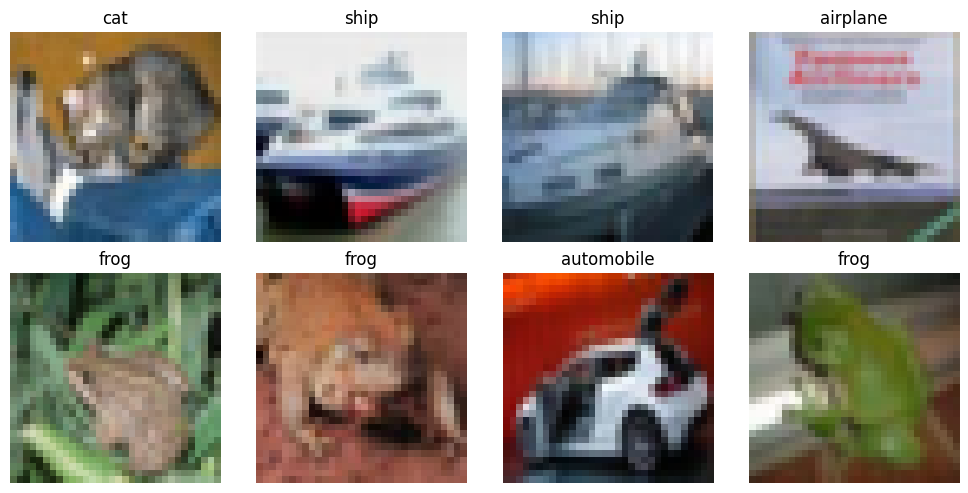

In [ ]:
classes = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
)

images, labels = next(iter(test_loader))

plt.figure(figsize=(10, 5))

for i in range(8):

    image = images[i] / 2 + 0.5
    image = image.permute(1, 2, 0)

    plt.subplot(2, 4, i + 1)

    plt.imshow(image)

    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()
